In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Kabileshwar RA2311026050170 SEAI")

Kabileshwar RA2311026050170 SEAI


In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
df = pd.read_csv(url, header=None)

df.columns = [
    "Pregnancies","Glucose","BloodPressure","SkinThickness",
    "Insulin","BMI","DiabetesPedigree","Age","Outcome"
]

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [6]:
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


d:\Projects\SEAI\main project\clinical_ai\venv_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running SHAP (final fix)...


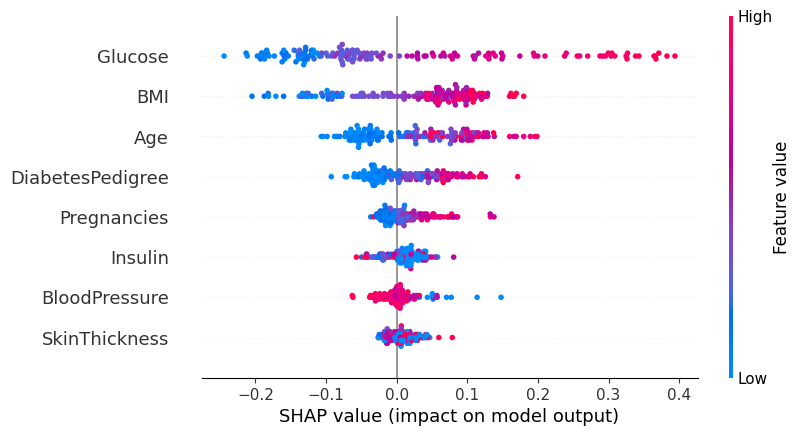

In [7]:
import shap

print("Running SHAP (final fix)...")

explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)

# Select ONLY class 1 (diabetes)
shap_values_class1 = shap_values[:, :, 1]

# Plot
shap.plots.beeswarm(shap_values_class1)

In [8]:
import pickle

# assuming your trained model is 'rf'
pickle.dump(rf, open("model.pkl", "wb"))

print("Model saved successfully")

Model saved successfully
